In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("World Energy Consumption.csv")

In [6]:
df.head

<bound method NDFrame.head of              country  year iso_code  population           gdp  \
0      ASEAN (Ember)  2000      NaN         NaN           NaN   
1      ASEAN (Ember)  2001      NaN         NaN           NaN   
2      ASEAN (Ember)  2002      NaN         NaN           NaN   
3      ASEAN (Ember)  2003      NaN         NaN           NaN   
4      ASEAN (Ember)  2004      NaN         NaN           NaN   
...              ...   ...      ...         ...           ...   
22007       Zimbabwe  2018      ZWE  15052191.0  2.271535e+10   
22008       Zimbabwe  2019      ZWE  15354606.0           NaN   
22009       Zimbabwe  2020      ZWE  15669663.0           NaN   
22010       Zimbabwe  2021      ZWE  15993525.0           NaN   
22011       Zimbabwe  2022      ZWE  16320539.0           NaN   

       biofuel_cons_change_pct  biofuel_cons_change_twh  \
0                          NaN                      NaN   
1                          NaN                      NaN   
2           

In [7]:
df.info

<bound method DataFrame.info of              country  year iso_code  population           gdp  \
0      ASEAN (Ember)  2000      NaN         NaN           NaN   
1      ASEAN (Ember)  2001      NaN         NaN           NaN   
2      ASEAN (Ember)  2002      NaN         NaN           NaN   
3      ASEAN (Ember)  2003      NaN         NaN           NaN   
4      ASEAN (Ember)  2004      NaN         NaN           NaN   
...              ...   ...      ...         ...           ...   
22007       Zimbabwe  2018      ZWE  15052191.0  2.271535e+10   
22008       Zimbabwe  2019      ZWE  15354606.0           NaN   
22009       Zimbabwe  2020      ZWE  15669663.0           NaN   
22010       Zimbabwe  2021      ZWE  15993525.0           NaN   
22011       Zimbabwe  2022      ZWE  16320539.0           NaN   

       biofuel_cons_change_pct  biofuel_cons_change_twh  \
0                          NaN                      NaN   
1                          NaN                      NaN   
2         

In [8]:
df.shape

(22012, 129)

In [9]:
df.isnull().sum()

country                       0
year                          0
iso_code                   5500
population                 3889
gdp                       10899
                          ...  
wind_elec_per_capita      14947
wind_electricity          14016
wind_energy_per_capita    17947
wind_share_elec           15126
wind_share_energy         17911
Length: 129, dtype: int64

In [4]:
df = df.dropna()
df = df.select_dtypes(include=[np.number])

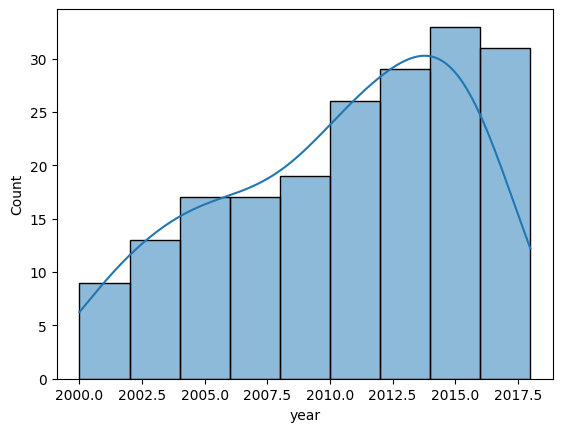

In [5]:
plt.figure()
sns.histplot(df.iloc[:,0], kde=True)
plt.show()

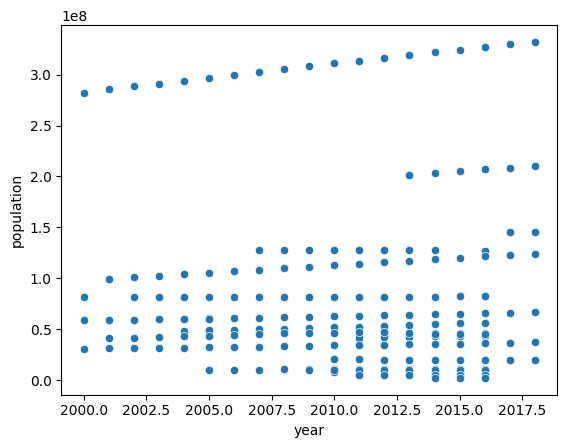

In [6]:
plt.figure()
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])
plt.show()

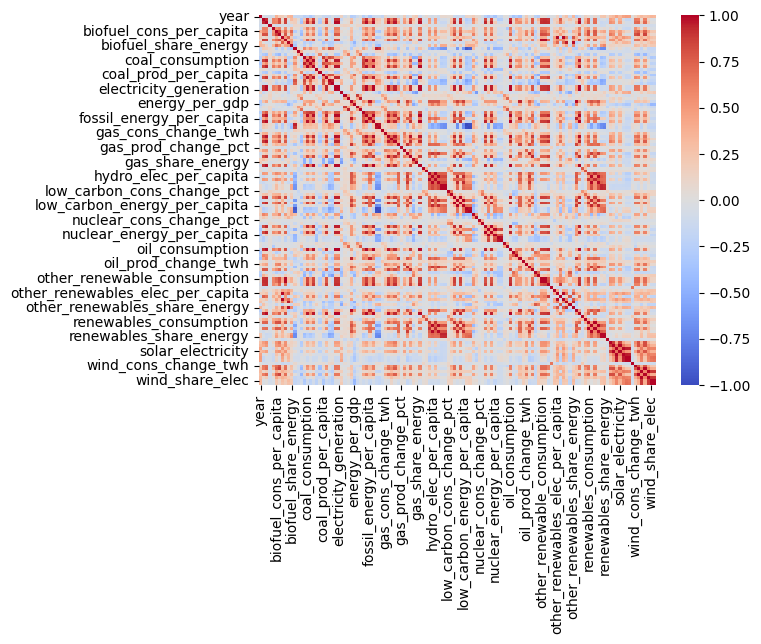

In [7]:
plt.figure()
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

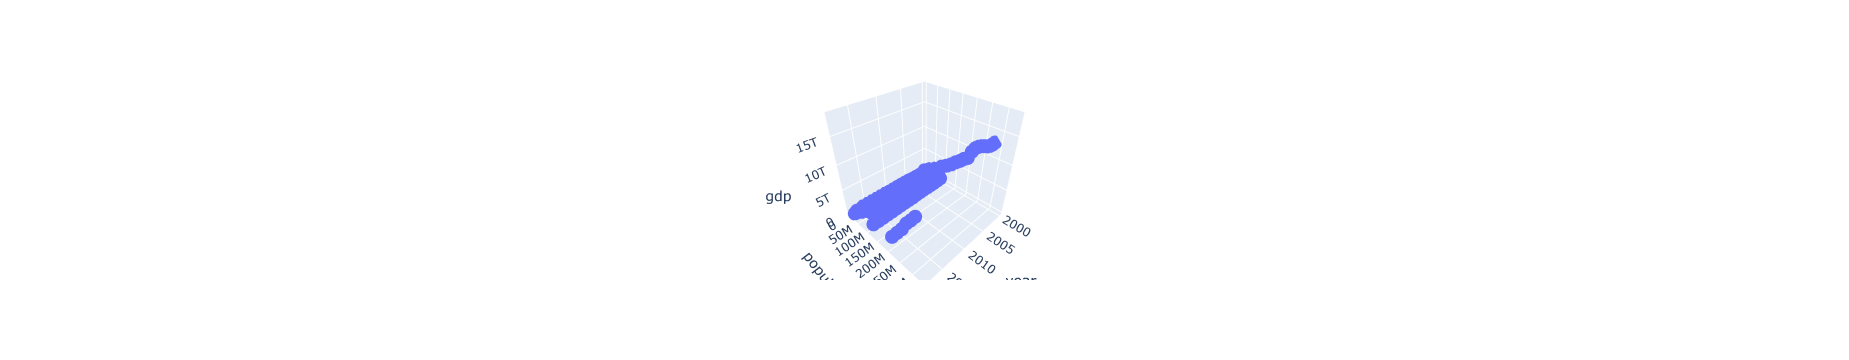

In [8]:
fig = px.scatter_3d(df, x=df.columns[0], y=df.columns[1], z=df.columns[2])
fig.show()

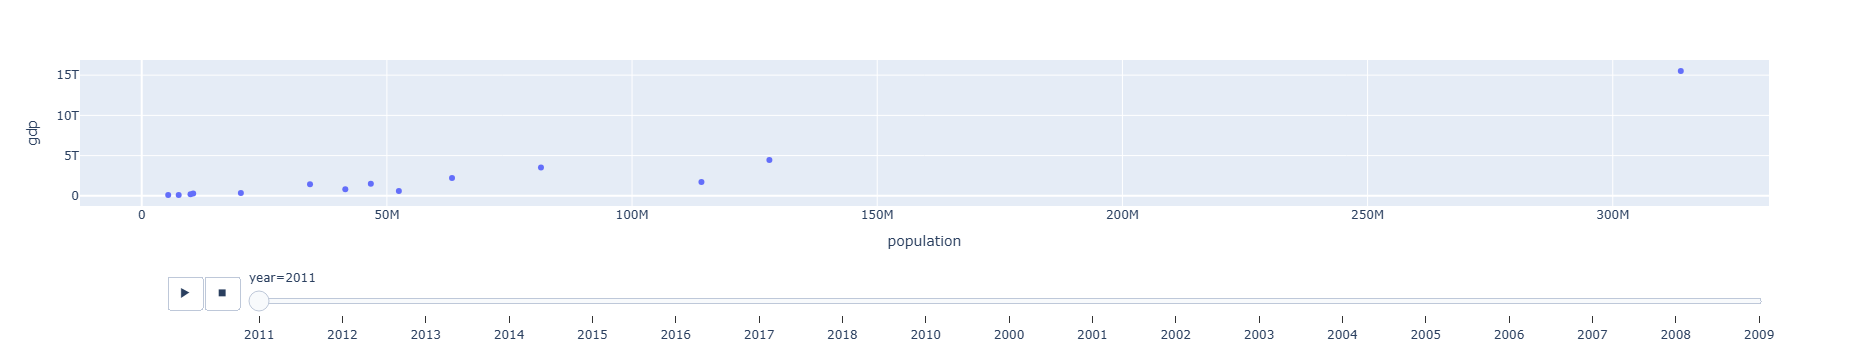

In [9]:
if 'year' in df.columns:
    fig2 = px.scatter(df, x=df.columns[1], y=df.columns[2], animation_frame='year')
    fig2.show()

In [10]:
if 'country' in df.columns:
    df_geo = pd.read_csv('World Energy Consumption.csv')
    if 'iso_code' in df_geo.columns and 'year' in df_geo.columns:
        fig3 = px.choropleth(df_geo.dropna(), locations='iso_code',
                             color=df_geo.columns[-1],
                             hover_name='country',
                             animation_frame='year')
        fig3.show()

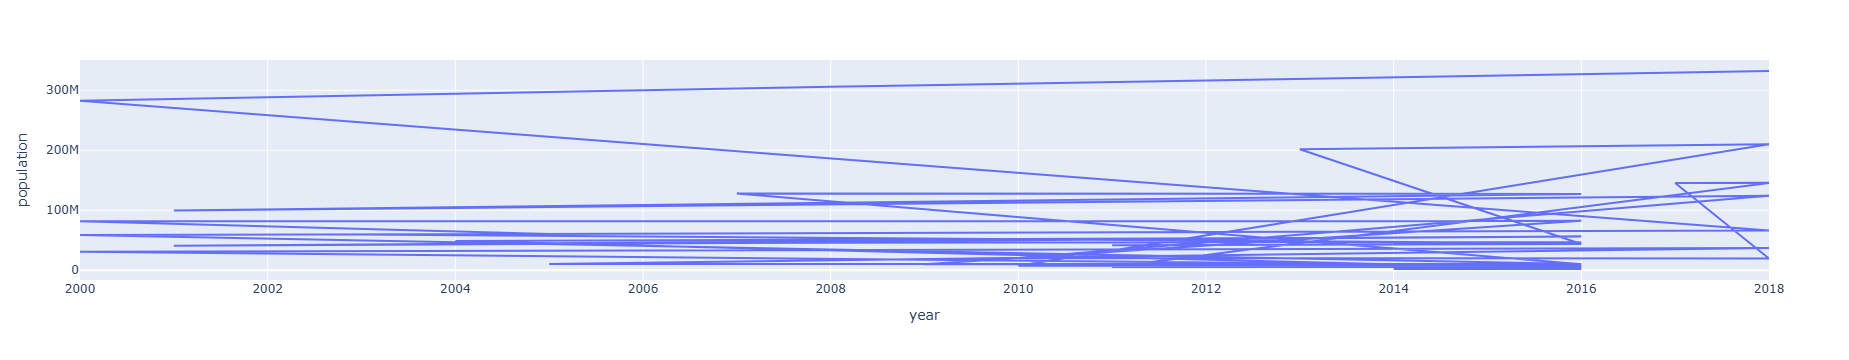

In [11]:
fig4 = px.line(df.head(500), x=df.columns[0], y=df.columns[1])
fig4.show()

In [12]:
X = df.drop(columns=[df.columns[-1]])
y = df[df.columns[-1]]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0)
model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=0)

In [15]:
preds = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

In [17]:
accuracy = r2 * 100

In [18]:

print("MAE:", mae)
print("R2 Score:", r2)
print("Model Accuracy (%):", accuracy)

MAE: 0.11373911553175549
R2 Score: 0.9930177931428532
Model Accuracy (%): 99.30177931428533
